In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
movies = pd.read_csv("dataset.csv")

In [3]:
movies.head()

,id,title,genre,original_language,overview,popularity,release_date,vote_average,vote_count
0,278,The Shawshank Redemption,"Drama,Crime",en,Framed in the 1940s for the double murder of h...,94.075,1994-09-23,8.7,21862
1,19404,Dilwale Dulhania Le Jayenge,"Comedy,Drama,Romance",hi,"Raj is a rich, carefree, happy-go-lucky second...",25.408,1995-10-19,8.7,3731
2,238,The Godfather,"Drama,Crime",en,"Spanning the years 1945 to 1955, a chronicle o...",90.585,1972-03-14,8.7,16280
3,424,Schindler's List,"Drama,History,War",en,The true story of how businessman Oskar Schind...,44.761,1993-12-15,8.6,12959
4,240,The Godfather: Part II,"Drama,Crime",en,In the continuing saga of the Corleone crime f...,57.749,1974-12-20,8.6,9811


In [4]:
movies.columns

Index(['id', 'title', 'genre', 'original_language', 'overview', 'popularity',
       'release_date', 'vote_average', 'vote_count'],
      dtype='object')

In [5]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 10000 non-null  int64  
 1   title              10000 non-null  object 
 2   genre              9997 non-null   object 
 3   original_language  10000 non-null  object 
 4   overview           9987 non-null   object 
 5   popularity         10000 non-null  float64
 6   release_date       10000 non-null  object 
 7   vote_average       10000 non-null  float64
 8   vote_count         10000 non-null  int64  
dtypes: float64(2), int64(2), object(5)
memory usage: 703.3+ KB


In [6]:
movies.isnull().sum()

,0
id,0
title,0
genre,3
original_language,0
overview,13
popularity,0
release_date,0
vote_average,0
vote_count,0


In [7]:
movies['genre'] = movies['genre'].fillna('Unknown')

In [8]:
movies['overview'] = movies['overview'].fillna('')

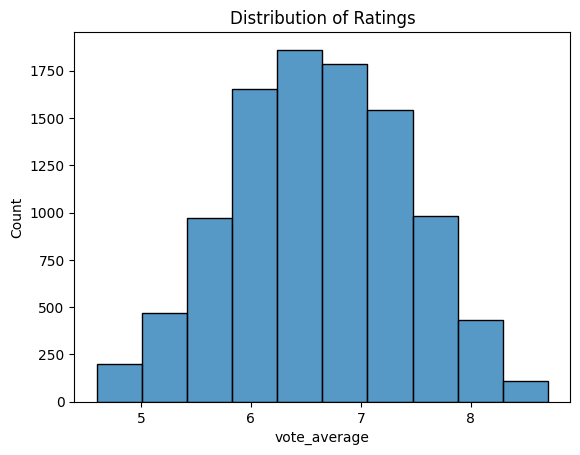

In [9]:
sns.histplot(movies['vote_average'], bins=10, kde=False)
plt.title("Distribution of Ratings")
plt.show()

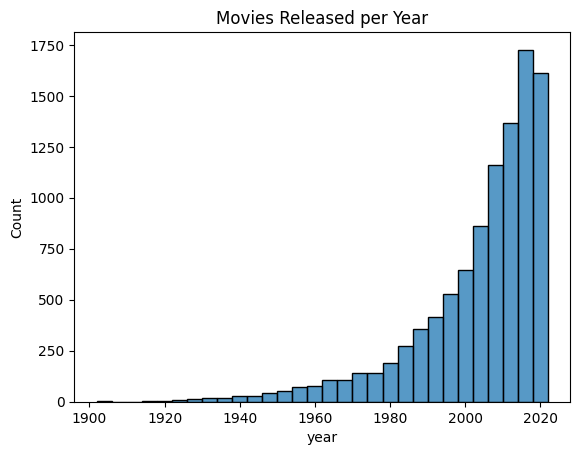

In [10]:
movies['year'] = pd.to_datetime(movies['release_date'], errors='coerce').dt.year
sns.histplot(movies['year'].dropna(), bins=30)
plt.title("Movies Released per Year")
plt.show()

In [11]:
movies['tags']=movies['genre'] + movies['overview']
# This merges textual metadata into one column.
# 'tags' will be the input for vectorization.

In [12]:
movies.head()

,id,title,genre,original_language,overview,popularity,release_date,vote_average,vote_count,year,tags
0,278,The Shawshank Redemption,"Drama,Crime",en,Framed in the 1940s for the double murder of h...,94.075,1994-09-23,8.7,21862,1994,"Drama,CrimeFramed in the 1940s for the double ..."
1,19404,Dilwale Dulhania Le Jayenge,"Comedy,Drama,Romance",hi,"Raj is a rich, carefree, happy-go-lucky second...",25.408,1995-10-19,8.7,3731,1995,"Comedy,Drama,RomanceRaj is a rich, carefree, h..."
2,238,The Godfather,"Drama,Crime",en,"Spanning the years 1945 to 1955, a chronicle o...",90.585,1972-03-14,8.7,16280,1972,"Drama,CrimeSpanning the years 1945 to 1955, a ..."
3,424,Schindler's List,"Drama,History,War",en,The true story of how businessman Oskar Schind...,44.761,1993-12-15,8.6,12959,1993,"Drama,History,WarThe true story of how busines..."
4,240,The Godfather: Part II,"Drama,Crime",en,In the continuing saga of the Corleone crime f...,57.749,1974-12-20,8.6,9811,1974,"Drama,CrimeIn the continuing saga of the Corle..."


In [13]:
movies.shape

(10000, 11)

In [14]:
new_df=movies[['id','title','genre','overview','tags']]

In [15]:
new_df=new_df.drop(columns=['genre','overview'])
new_df.head()

,id,title,tags
0,278,The Shawshank Redemption,"Drama,CrimeFramed in the 1940s for the double ..."
1,19404,Dilwale Dulhania Le Jayenge,"Comedy,Drama,RomanceRaj is a rich, carefree, h..."
2,238,The Godfather,"Drama,CrimeSpanning the years 1945 to 1955, a ..."
3,424,Schindler's List,"Drama,History,WarThe true story of how busines..."
4,240,The Godfather: Part II,"Drama,CrimeIn the continuing saga of the Corle..."


In [16]:
# Step 6: Vectorization (TF-IDF instead of CountVectorizer)
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000, stop_words='english')

# TF-IDF converts text into numerical vectors.
# max_features=10000 → limits vocabulary size.
# stop_words='english' → removes common words like "the", "and".
# vec.shape → shows dimensions (#movies, #features).

(10000, 10000)

In [17]:
vec = tfidf.fit_transform(new_df['tags'].values.astype('U')).toarray()

In [18]:
vec

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [19]:
vec.shape

(10000, 10000)

In [20]:
from sklearn.metrics.pairwise import cosine_similarity

In [21]:
sim=cosine_similarity(vec)

In [22]:
sim

array([[1.        , 0.02024503, 0.01071618, ..., 0.06151744, 0.04295179,
        0.02423265],
       [0.02024503, 1.        , 0.01731476, ..., 0.        , 0.        ,
        0.        ],
       [0.01071618, 0.01731476, 1.        , ..., 0.01302819, 0.01947418,
        0.        ],
       ...,
       [0.06151744, 0.        , 0.01302819, ..., 1.        , 0.00712494,
        0.00666356],
       [0.04295179, 0.        , 0.01947418, ..., 0.00712494, 1.        ,
        0.01131156],
       [0.02423265, 0.        , 0.        , ..., 0.00666356, 0.01131156,
        1.        ]])

In [23]:
new_df[new_df['title']=='The Shawshank Redemption']

,id,title,tags
0,278,The Shawshank Redemption,"Drama,CrimeFramed in the 1940s for the double ..."


In [24]:
dist=sorted(list(enumerate(sim[0])),reverse=True,key=lambda vec:vec[1])

In [25]:
dist

[(0, np.float64(1.0000000000000002)),
 (6156, np.float64(0.17838495332228013)),
 (791, np.float64(0.15512574484203404)),
 (5182, np.float64(0.150494190357306)),
 (2991, np.float64(0.1465671743018731)),
 (4330, np.float64(0.1427300627796791)),
 (6277, np.float64(0.14210538794742195)),
 (9006, np.float64(0.1378695548832455)),
 (4086, np.float64(0.13660150339647584)),
 (698, np.float64(0.13647961951452725)),
 (6561, np.float64(0.13382541380952467)),
 (4490, np.float64(0.1329306667569251)),
 (1009, np.float64(0.13060327328487115)),
 (87, np.float64(0.13019165223279835)),
 (617, np.float64(0.1295822706699436)),
 (3649, np.float64(0.1288451386228796)),
 (4068, np.float64(0.12841939650545373)),
 (7871, np.float64(0.1253429602002973)),
 (3250, np.float64(0.12172861710535444)),
 (2927, np.float64(0.12166768362191849)),
 (170, np.float64(0.11975573053524254)),
 (6402, np.float64(0.11900214968757458)),
 (1970, np.float64(0.11774676312007787)),
 (8832, np.float64(0.11773769471873811)),
 (8640, np.

In [26]:
for i in dist[0:5]:
  print(new_df.iloc[i[0]].title)

The Shawshank Redemption
In Hell
The Chorus
The Longest Yard
Brubaker


In [27]:
def recommend(movies):
  index=new_df[new_df['title']==movies].index[0]
  distance=sorted(list(enumerate(sim[index])),reverse=True,key=lambda vec:vec[1])
  for i in distance[0:5]:
    print(new_df.iloc[i[0]].title)

In [28]:
recommend('Iron Man')

Iron Man
Iron Man 2
Iron Man 3
Clown
Avengers: Age of Ultron


In [29]:
movie = input("Enter a movie: ")
recommend(movie)

Enter a movie: Dilwale Dulhania Le Jayenge
Dilwale Dulhania Le Jayenge
A Passage to India
Padmaavat
The Cheetah Girls: One World
The Kid with a Bike
